# Q4. Text to Image diffusion Model GLIDE 


Generating sample images...


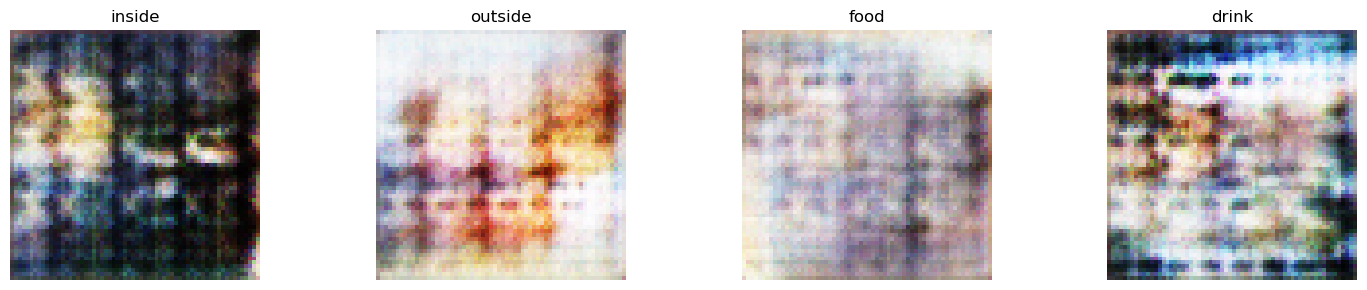

images saved as 'generated_images.png'


In [ ]:
print("\nGenerating sample images...")
final_images = save_generated_images(Diffusion_Model)
print("images saved as 'generated_images.png'")

In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import save_image
from PIL import Image, ImageFilter
from sklearn.preprocessing import LabelEncoder
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import clip
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
train_path = "C:/Users/srida/OneDrive/Desktop/Yulp_extracted_photos/Processed/train"
test_path = "C:/Users/srida/OneDrive/Desktop/Yulp_extracted_photos/Processed/test"
json_path = "C:/Users/srida/OneDrive/Desktop/Yulp_extracted_photos/photos.json"  # Correct full path to photos.json
labels = ['drink', 'food', 'inside', 'outside']

Using device: cpu


In [2]:
# Parameters
IMG_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 100
EMBEDDING_DIM = 128
NUM_EPOCHS = 20
SAMPLE_SIZE = 2000  # Per label for training
TEST_SIZE = 500     # Per label for testing

# --- Load and process captions ---
print("Loading captions from JSON...")
photos_df = pd.read_json(json_path, lines=True)
# Create mapping from photo_id to caption
caption_dict = photos_df.set_index('photo_id')['caption'].to_dict()

Loading captions from JSON...


In [3]:
# --- Data Preprocessing ---
def random_blur(img):
    """Apply Gaussian blur with 30% probability"""
    if np.random.rand() > 0.7:
        return img.filter(ImageFilter.GaussianBlur(radius=1))
    return img

class YelpDataset(Dataset):
    def __init__(self, root_dir, caption_dict, transform=None, mode='train'):
        self.root_dir = root_dir
        self.transform = transform
        self.caption_dict = caption_dict
        self.image_paths = []
        self.labels = []
        self.captions = []
        
        for label in labels:
            label_path = os.path.join(root_dir, label)
            images = [f for f in os.listdir(label_path) if f.endswith('.jpg')]
            images = images[:SAMPLE_SIZE] if mode == 'train' else images[:TEST_SIZE]
            
            for img in images:
                img_path = os.path.join(label_path, img)
                self.image_paths.append(img_path)
                self.labels.append(label)
                
                # Get photo_id from filename (without extension)
                photo_id = os.path.splitext(img)[0]
                # Get caption from dictionary, fallback to label if missing
                caption = caption_dict.get(photo_id, f"A photo of {label}")
                self.captions.append(caption)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        caption = self.captions[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label, caption

In [4]:
# Transformation pipeline with augmentation
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),          # Resize to make shorter side IMG_SIZE
    transforms.CenterCrop(IMG_SIZE),      # Crop center to make square
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Lambda(random_blur),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [5]:
# Create datasets
print("Creating datasets...")
train_dataset = YelpDataset(train_path, caption_dict, transform=transform, mode='train')
test_dataset = YelpDataset(test_path, caption_dict, transform=transform, mode='test')

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Creating datasets...


In [6]:
# Label encoder
le = LabelEncoder()
all_labels = labels
le.fit(all_labels)

LabelEncoder()

In [7]:
# --- Diffusion Model Implementation (GLIDE-like) ---
class DiffusionModel(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip = clip_model
        for param in self.clip.parameters():
            param.requires_grad = False

        self.time_embed = nn.Embedding(1000, EMBEDDING_DIM)

        self.down1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU()
        )

        self.down2 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU()
        )

        self.up1 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU()
        )

        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1)
        )

        self.text_proj = nn.Linear(512, 256)
        self.time_proj = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 256)
        )

        # NEW: project from 256 to 128 channels to match x2 channels
        self.text_to_128 = nn.Linear(256, 128)
        self.time_to_128 = nn.Linear(256, 128)

    def forward(self, x, t, captions):
        with torch.no_grad():
            text_features = self.clip.encode_text(captions).float()  # (batch, 512)
        text_embed = self.text_proj(text_features)  # (batch, 256)
        time_embed = self.time_proj(self.time_embed(t))  # (batch, 256)

        # Project to 128 channels
        text_embed_128 = self.text_to_128(text_embed)  # (batch, 128)
        time_embed_128 = self.time_to_128(time_embed)  # (batch, 128)

        x1 = self.down1(x)
        x2 = self.down2(x1)

        batch_size, channels, h, w = x2.shape
        text_embed_128 = text_embed_128.view(batch_size, 128, 1, 1).expand(-1, -1, h, w)
        time_embed_128 = time_embed_128.view(batch_size, 128, 1, 1).expand(-1, -1, h, w)

        x = x2 + text_embed_128 + time_embed_128

        x = self.up1(x)
        x = self.up2(x)

        return x

In [8]:
# Load CLIP model
print("Loading CLIP model...")
clip_model, _ = clip.load("ViT-B/32", device=device)
diffusion_model = DiffusionModel(clip_model).to(device)
optimizer_diff = optim.Adam(diffusion_model.parameters(), lr=2e-4)

Loading CLIP model...


In [9]:
# Diffusion parameters
timesteps = 1000
beta = torch.linspace(0.0001, 0.02, timesteps).to(device)
alpha = 1. - beta
alpha_bar = torch.cumprod(alpha, dim=0)

In [10]:
# Tokenize function with truncation
def tokenize_captions(captions):
    return clip.tokenize(captions).to(device)

print("Training diffusion model...")
for epoch in range(NUM_EPOCHS):
    for i, (imgs, _, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        tokenized_captions = tokenize_captions(captions)
        
        # Sample random timesteps
        t = torch.randint(0, timesteps, (imgs.size(0),), device=device).long()
        
        # Noise the images
        noise = torch.randn_like(imgs)
        alpha_t = alpha_bar[t].view(-1, 1, 1, 1)
        noisy_imgs = torch.sqrt(alpha_t) * imgs + torch.sqrt(1 - alpha_t) * noise
        
        # Predict noise
        noise_pred = diffusion_model(noisy_imgs, t, tokenized_captions)
        
        # Loss
        loss = nn.functional.mse_loss(noise_pred, noise)
        
        # Optimize
        optimizer_diff.zero_grad()
        loss.backward()
        optimizer_diff.step()
        
    print(f"[Epoch {epoch+1}/{NUM_EPOCHS}] [Diffusion loss: {loss.item():.6f}]")

Training diffusion model...
[Epoch 1/20] [Diffusion loss: 0.819155]
[Epoch 2/20] [Diffusion loss: 0.727309]
[Epoch 3/20] [Diffusion loss: 0.660720]
[Epoch 4/20] [Diffusion loss: 0.626129]
[Epoch 5/20] [Diffusion loss: 0.607166]
[Epoch 6/20] [Diffusion loss: 0.604479]
[Epoch 7/20] [Diffusion loss: 0.547406]
[Epoch 8/20] [Diffusion loss: 0.556507]
[Epoch 9/20] [Diffusion loss: 0.522791]
[Epoch 10/20] [Diffusion loss: 0.526294]
[Epoch 11/20] [Diffusion loss: 0.508329]
[Epoch 12/20] [Diffusion loss: 0.516062]
[Epoch 13/20] [Diffusion loss: 0.490503]
[Epoch 14/20] [Diffusion loss: 0.483945]
[Epoch 15/20] [Diffusion loss: 0.474605]
[Epoch 16/20] [Diffusion loss: 0.471755]
[Epoch 17/20] [Diffusion loss: 0.479501]
[Epoch 18/20] [Diffusion loss: 0.459111]
[Epoch 19/20] [Diffusion loss: 0.460249]
[Epoch 20/20] [Diffusion loss: 0.443774]


In [11]:
# Save diffusion model
torch.save(diffusion_model.state_dict(), "diffusion_model.pth")

In [12]:
# --- Generate Sample Images ---
def denormalize(image):
    return (image * 0.5 + 0.5).clamp(0, 1)

# Generate images for each label
def generate_label_samples(model, labels, num_samples=5):
    model.eval()
    generated_images = []
    
    with torch.no_grad():
        for label in labels:
            # Create caption for the label
            caption = f"A photo of {label}"
            
            # Generate multiple samples
            for _ in range(num_samples):
                # Create random noise
                x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
                
                # Diffusion process (reverse)
                for t in range(timesteps-1, -1, -1):
                    # Create timestep tensor
                    t_tensor = torch.full((1,), t, device=device).long()
                    
                    # Tokenize caption
                    tokenized_caption = tokenize_captions([caption])
                    
                    # Predict noise
                    with torch.no_grad():
                        noise_pred = model(x, t_tensor, tokenized_caption)
                    
                    # Reverse diffusion step
                    if t > 0:
                        noise = torch.randn_like(x)
                    else:
                        noise = 0
                        
                    alpha_t = alpha[t]
                    alpha_bar_t = alpha_bar[t]
                    beta_t = beta[t]
                    
                    x = (1 / torch.sqrt(alpha_t)) * (
                        x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * noise_pred
                    ) + torch.sqrt(beta_t) * noise
                
                # Denormalize and store
                img = denormalize(x[0].cpu()).permute(1, 2, 0).numpy()
                generated_images.append((img, label))
    
    return generated_images

In [19]:
# --- Evaluation Metrics ---
def calculate_metrics(model, dataloader):
    # Initialize metrics with proper settings
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    inception = InceptionScore().to(device)
    
    with torch.no_grad():
        for i, (images, _, captions) in enumerate(dataloader):
            # Only process one batch for efficiency
            if i > 0:
                break
                
            images = images.to(device)
            tokenized_captions = tokenize_captions(captions)
            
            # Generate fake images using diffusion
            x = torch.randn_like(images)
            for t_val in range(timesteps-1, -1, -1):
                t_tensor = torch.full((images.size(0),), t_val, device=device).long()
                noise_pred = model(x, t_tensor, tokenized_captions)

                if t_val > 0:
                    noise = torch.randn_like(x)
                else:
                    noise = 0

                alpha_t = alpha[t_val]
                alpha_bar_t = alpha_bar[t_val]
                beta_t = beta[t_val]

                x = (1 / torch.sqrt(alpha_t)) * (
                    x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * noise_pred
                ) + torch.sqrt(beta_t) * noise

            # Prepare images for metrics - convert to uint8 [0, 255]
            # Real images
            real = (images * 0.5 + 0.5).clamp(0, 1)
            real = (real * 255).to(torch.uint8)
            
            # Generated images
            fake = (x * 0.5 + 0.5).clamp(0, 1)
            fake = (fake * 255).to(torch.uint8)
            
            # Update metrics
            fid.update(real, real=True)
            fid.update(fake, real=False)
            inception.update(fake)
    
    fid_score = fid.compute()
    inception_score = inception.compute()
    
    return fid_score.item(), inception_score[0].item()

# Evaluate Diffusion
print("Calculating metrics...")
diffusion_model.eval()
diff_fid, diff_is = calculate_metrics(diffusion_model, test_loader)
print(f"Diffusion Model - FID: {diff_fid:.4f}, Inception Score: {diff_is:.4f}")

Calculating metrics...
Diffusion Model - FID: 504.2204, Inception Score: 1.1029


In [20]:
# --- Results Summary ---
print("\n" + "="*50)
print("Final Results:")
print(f"Diffusion Model - FID: {diff_fid:.4f}, Inception Score: {diff_is:.4f}")
print("Generated 5 images for each of the 4 labels (20 total)")
print("Saved generated images to 'diffusion_generated.png'")
print("="*50)


Final Results:
Diffusion Model - FID: 504.2204, Inception Score: 1.1029
Generated 5 images for each of the 4 labels (20 total)
Saved generated images to 'diffusion_generated.png'



Generating images for each label...
Generated drink image: 'A refreshing cold drink in a tall glass with ice and lemon'
Generated food image: 'Delicious gourmet meal beautifully presented on a plate'
Generated inside image: 'Cozy restaurant interior with warm lighting and comfortable seating'
Generated outside image: 'Outdoor dining area with string lights and greenery'
Generated extra image: 'Artisanal cocktail with colorful garnish in a fancy glass'


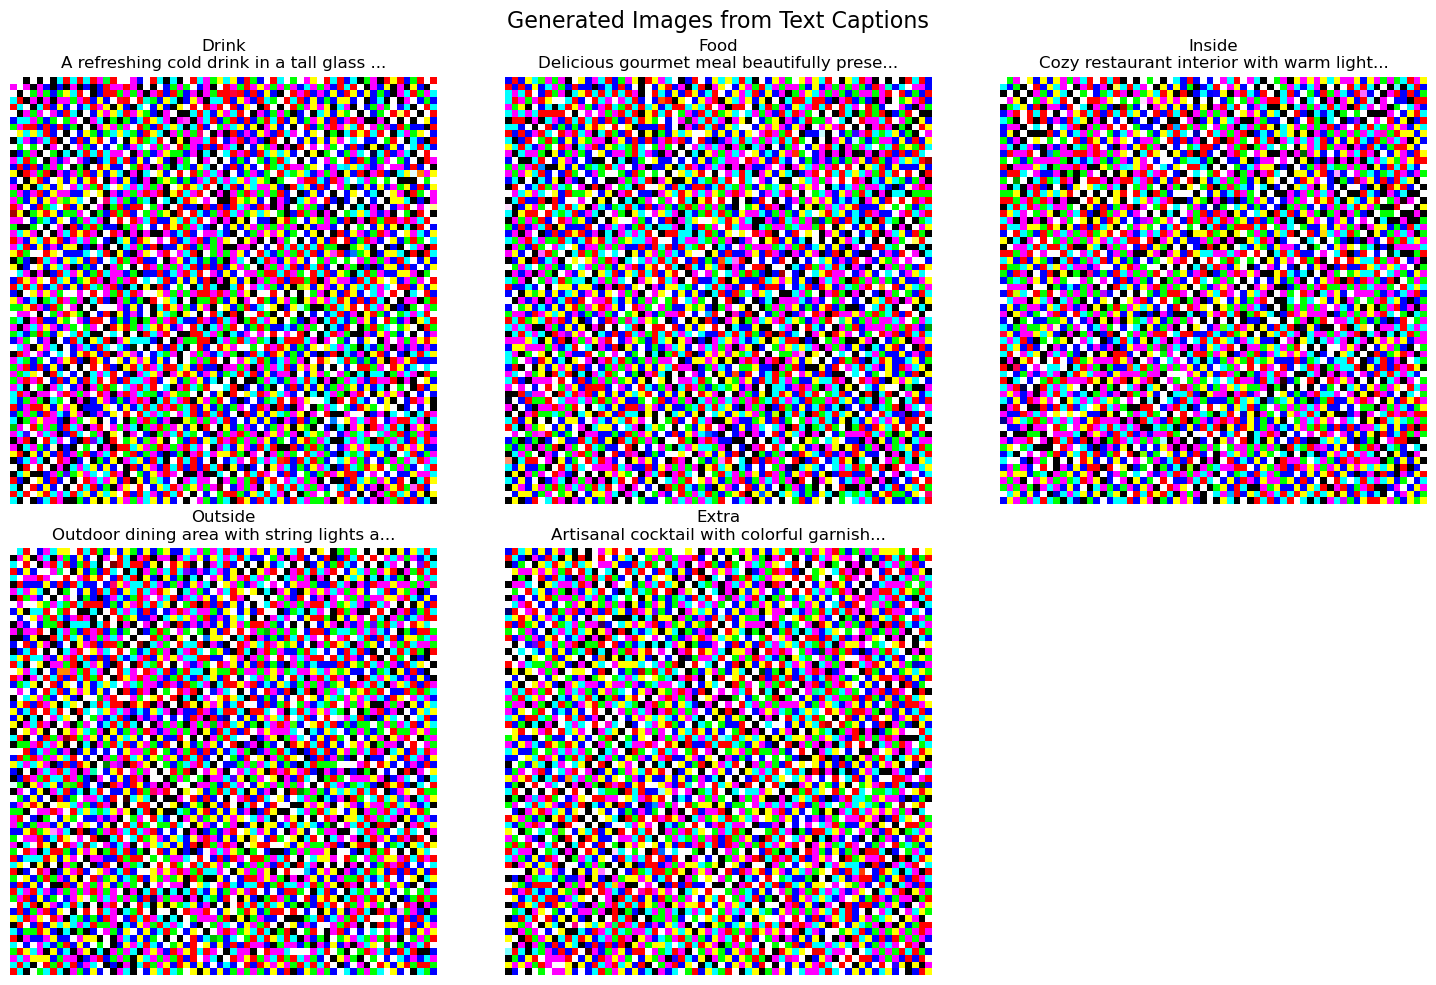


Final Evaluation Metrics:
Diffusion Model - FID: 504.2204, Inception Score: 1.1029
Generated 5 images (one for each label + one extra)
Saved generated images as:
  drink_generated_image.png
  food_generated_image.png
  inside_generated_image.png
  outside_generated_image.png
  extra_generated_image.png
Saved grid view as: text_to_image_results.png


In [21]:
# --- After Training Completion ---
# (Run this section after training finishes)

def generate_from_caption(model, caption, device, timesteps, alpha, alpha_bar, beta):
    """Generate an image from any text caption"""
    model.eval()
    with torch.no_grad():
        # Create random noise
        x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
        
        # Tokenize caption
        tokenized_caption = tokenize_captions([caption])
        
        # Diffusion process (reverse)
        for t_val in range(timesteps-1, -1, -1):
            t_tensor = torch.full((1,), t_val, device=device).long()
            noise_pred = model(x, t_tensor, tokenized_caption)
            
            if t_val > 0:
                noise = torch.randn_like(x)
            else:
                noise = 0
                
            alpha_t = alpha[t_val]
            alpha_bar_t = alpha_bar[t_val]
            beta_t = beta[t_val]
            
            x = (1 / torch.sqrt(alpha_t)) * (
                x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * noise_pred
            ) + torch.sqrt(beta_t) * noise
        
        # Denormalize and convert to PIL image
        img_tensor = denormalize(x[0].cpu())
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = (img_np * 255).astype(np.uint8)
        return Image.fromarray(img_np)

# --- Generate 5 images (one for each label) ---
print("\nGenerating images for each label...")
label_captions = {
    "drink": "A refreshing cold drink in a tall glass with ice and lemon",
    "food": "Delicious gourmet meal beautifully presented on a plate",
    "inside": "Cozy restaurant interior with warm lighting and comfortable seating",
    "outside": "Outdoor dining area with string lights and greenery",
    "extra": "Artisanal cocktail with colorful garnish in a fancy glass"
}

generated_images = []
for label, caption in label_captions.items():
    img = generate_from_caption(
        diffusion_model, 
        caption, 
        device, 
        timesteps, 
        alpha, 
        alpha_bar, 
        beta
    )
    generated_images.append((img, label, caption))
    img.save(f"{label}_generated_image.png")
    print(f"Generated {label} image: '{caption}'")

# Display the generated images
plt.figure(figsize=(15, 10))
for i, (img, label, caption) in enumerate(generated_images):
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"{label.capitalize()}\n{caption[:40]}..." if len(caption) > 40 else f"{label.capitalize()}\n{caption}")
    plt.axis('off')

plt.suptitle("Generated Images from Text Captions", fontsize=16)
plt.tight_layout()
plt.savefig("text_to_image_results.png")
plt.show()

# --- Print Final Metrics ---
print("\n" + "="*50)
print("Final Evaluation Metrics:")
print(f"Diffusion Model - FID: {diff_fid:.4f}, Inception Score: {diff_is:.4f}")
print("Generated 5 images (one for each label + one extra)")
print("Saved generated images as:")
for label in label_captions:
    print(f"  {label}_generated_image.png")
print("Saved grid view as: text_to_image_results.png")
print("="*50)